In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('./data1.csv')

In [3]:
df

,rating,net_payable,work_hours,leave_days,risk_score,promotion_recommendations,predicted_growth_years,mood_index
0,4,23022,488,2,0.66,0,3,0.79
1,3,44832,508,3,0.36,0,5,0.87
2,3,50051,499,4,0.64,0,4,0.65
3,3,56429,500,2,0.63,1,2,0.76
4,2,42995,501,4,0.41,0,1,0.43
...,...,...,...,...,...,...,...,...
86359,2,20842,485,2,0.75,0,4,0.47
86360,1,28352,501,4,0.47,0,3,0.21
86361,3,73632,504,3,0.29,0,5,0.89
86362,5,51479,489,4,0.68,1,2,1.00


In [4]:
df['mood_index'].value_counts()

mood_index
1.00    2500
0.76    1678
0.69    1666
0.78    1633
0.73    1623
        ... 
0.11       7
0.15       5
0.10       2
0.12       2
0.09       1
Name: count, Length: 92, dtype: int64

In [5]:
df.describe()

,rating,net_payable,work_hours,leave_days,risk_score,promotion_recommendations,predicted_growth_years,mood_index
count,86364.000000,86364.000000,86364.000000,86364.000000,86364.000000,86364.000000,86364.000000,86364.000000
mean,2.772799,48897.122377,495.217602,3.035049,0.530234,0.439720,2.926219,0.695276
std,1.362734,17224.089128,8.930104,0.816564,0.158432,0.496356,1.425695,0.185661
min,1.000000,20000.000000,480.000000,2.000000,0.250000,0.000000,1.000000,0.090000
25%,2.000000,34003.750000,488.000000,2.000000,0.390000,0.000000,2.000000,0.560000
50%,3.000000,48299.500000,495.000000,3.000000,0.530000,0.000000,3.000000,0.710000
75%,4.000000,63597.250000,503.000000,4.000000,0.670000,1.000000,4.000000,0.840000
max,5.000000,80000.000000,510.000000,4.000000,0.800000,1.000000,5.000000,1.000000


In [6]:
import tensorflow
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, BatchNormalization, Dropout
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import StandardScaler
from keras.optimizers import Adam

2025-06-30 16:33:54.803941: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751281434.819144  266407 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751281434.824005  266407 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1751281434.838786  266407 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1751281434.838814  266407 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1751281434.838816  266407 computation_placer.cc:177] computation placer alr

In [7]:
X = df.iloc[:,0:-1].values

In [8]:
X.shape

(86364, 7)

In [9]:
y = df.iloc[:,-1].values

In [10]:
y.shape

(86364,)

In [11]:
X_tr , X_te , y_tr , y_te = train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
sc = StandardScaler()
X_tr_scaled = sc.fit_transform(X_tr)
X_te_scaled = sc.transform(X_te)

In [13]:
X_tr_scaled[0]

array([-0.56411129,  1.2867814 , -1.48018051, -1.26828546, -1.00840969,
        1.13044261,  0.05114098])

In [14]:
model = Sequential()

model.add(Dense(32,activation='relu',input_shape=(7,)))
model.add(Dense(32,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(1,activation='linear'))

/home/nikhilds/anaconda3/envs/tf/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-06-30 16:33:57.395221: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_UNKNOWN: unknown error
2025-06-30 16:33:57.395246: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:178] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
2025-06-30 16:33:57.395251: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:183] retrieving CUDA diagnostic information for host: nikidev
2025-06-30 16:33:57.395254: I external/local

In [15]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

In [16]:
history = model.fit(X_tr_scaled, y_tr, epochs=20, batch_size=32, validation_split=0.2)

Epoch 1/20
1728/1728 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0391 - mae: 0.1185 - val_loss: 0.0030 - val_mae: 0.0437
Epoch 2/20
1728/1728 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0029 - mae: 0.0433 - val_loss: 0.0026 - val_mae: 0.0401
Epoch 3/20
1728/1728 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0027 - mae: 0.0411 - val_loss: 0.0025 - val_mae: 0.0401
Epoch 4/20
1728/1728 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0026 - mae: 0.0405 - val_loss: 0.0024 - val_mae: 0.0389
Epoch 5/20
1728/1728 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0025 - mae: 0.0398 - val_loss: 0.0025 - val_mae: 0.0397
Epoch 6/20
1728/1728 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0025 - mae: 0.0396 - val_loss: 0.0025 - val_mae: 0.0392
Epoch 7/20
1728/1728 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0025 - mae: 0.0396 - val_loss: 0.0024 - val_mae: 0.0389
Epoch 8/20
1728/1728 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0025 - mae: 0.0395 - val_loss: 0.0024 - val_mae: 0.0390
Epoch 9/20
1728/1728 ━━━━━━━━━━━━━━━━━━━

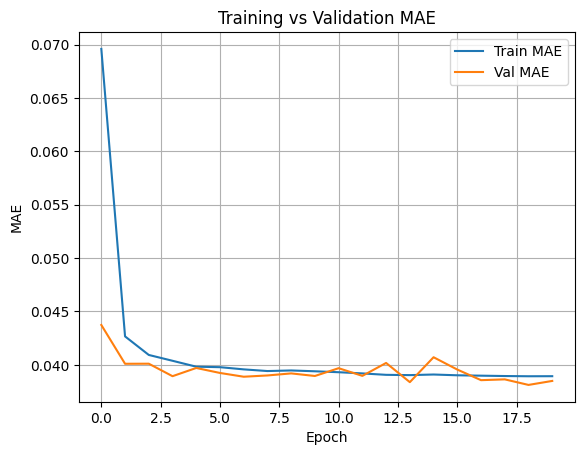

In [17]:
import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Training vs Validation MAE')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
from sklearn.metrics import mean_squared_error, r2_score

# Predict on the test set
y_pred = model.predict(X_te_scaled)

# Calculate MSE
mse = mean_squared_error(y_te, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")

# Calculate R² Score
r2 = r2_score(y_te, y_pred)
print(f"R² Score: {r2:.4f}")

540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 540us/step
Mean Squared Error (MSE): 0.0024
R² Score: 0.9291


In [20]:
model.save("mood_model.keras")